# Computer Vision Exam #2

Name: Juan Diego Perez  
Code: T00067699

In [160]:
import numpy as np
import cv2
import matplotlib.pylab as plt
import urllib.request


CONNECTIVITY: int = 8
AREA_MIN: int = 20

In [161]:
def plot_grayscale(
    image: np.ndarray,
    ax: plt.Axes = None,
    axis_off: bool = True,
    **kwargs
) -> None:
    """
    Display a grayscale image using matplotlib.
    
    Parameters:
        image (numpy.ndarray): The grayscale image to display.
        ax (matplotlib.axes.Axes, optional): The axes to plot on. If None, a new figure is created.
        axis_off (bool, optional): If True, turn off the axis. Defaults to True.
    """
    if ax is None:
        _, ax = plt.subplots()
    ax.imshow(image, cmap='gray')
    ax.set(**kwargs)
    if axis_off:
        ax.axis('off')


def filter_stats(stats: np.ndarray) -> bool:
    """"
    Filter based on stats if its a blob or not.

    Parameters:
        stats (numpy.ndarray): A 1-D array representing the stats of the blob.

    Returns:
        bool: True if the blob is valid, False otherwise.
    """
    area = stats[cv2.CC_STAT_AREA]
    width = stats[cv2.CC_STAT_WIDTH]
    height = stats[cv2.CC_STAT_HEIGHT]

    # Filter by area
    is_valid_area = AREA_MIN < area
    is_valid_width = width > 0
    is_valid_height = height > 0

    return is_valid_area and is_valid_width and is_valid_height

## Exercise 1 (connected components and morphological operations)

(512, 512)


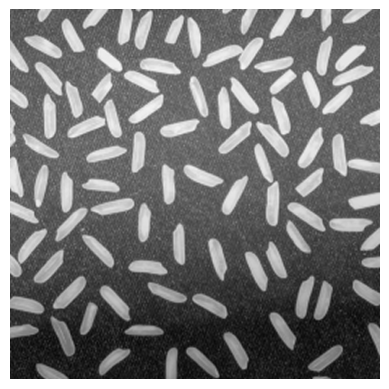

In [162]:
IMAGE_URL = 'https://raw.githubusercontent.com/fquinterov/computer_vision_course/main/resources/images/rice.png'

urllib.request.urlretrieve(IMAGE_URL, 'images/rice.png')

rice = cv2.imread('images/rice.png')

img_rice = cv2.cvtColor(rice, cv2.COLOR_BGR2GRAY)
print(img_rice.shape)
plt.imshow(img_rice, cmap='gray')
plt.axis('off')
plt.show()

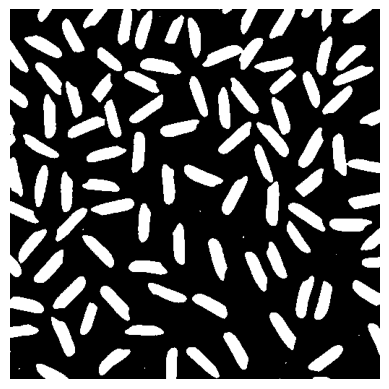

In [163]:
output_adapthresh = cv2.adaptiveThreshold(img_rice, 255.0, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 51, -20.0)
plt.imshow(output_adapthresh, cmap='gray')
plt.axis('off')
plt.show()

En teoría, hay 100 granos de arroz y dos de ellos están bastante unidos. El cuarto de los granos de arroz que pasan de la imagen no se está tomando en cuenta (gracias a dios, un número cuadrado). Si sí se tuviera en cuenta, solo bastaría cambiar la constante `AREA_MIN` a `AREA_MIN: int = 10`. Así sí se tendría en cuenta y habría un total de 101 granos de arroz. Si se quisiera graficar, es mejor asumir que todo está bien... o bueno, si verificar cada uno, ajustar el `figsize`, número de filas y columnas e inclusive usar la función `plt.savefig()`; pero está en cada quién esa decisión.

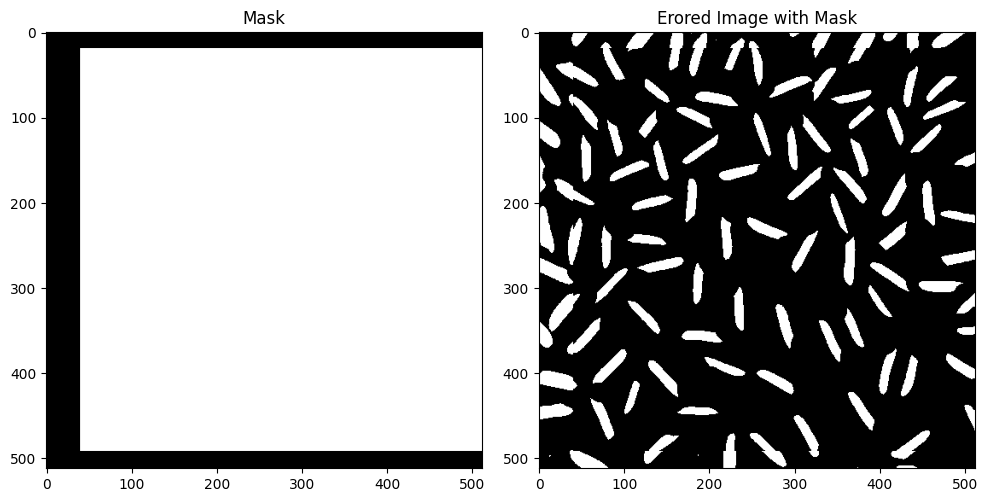

In [164]:
mask = np.zeros(output_adapthresh.shape, dtype=np.uint8)

x, y, width, height = 40, 20, 472, 472
mask[y:y+height, x:x+width] = 255

result = output_adapthresh.copy()

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (6, 6))
eroded_region = cv2.erode(output_adapthresh, kernel)
result = np.where(mask[:, :]==255, eroded_region, result)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_grayscale(mask, axes[0], False, title='Mask')
plot_grayscale(result, axes[1], False, title='Erored Image with Mask')
fig.tight_layout()
plt.show()

La razón por la cual estoy utilizando este tema de máscaras, es debido a que es para indicar que no todo quiero que se le haga la operación de erosión, solamente lo que está en blanco de la máscara, y es porque los granos de arroz que están los bordes arriba, abajo e izquierda son bastante sensibles a esta operación, sensibles en el sentido de perder el grano en sí, esa es la razón detrás de la técnica usada

In [165]:
output = cv2.connectedComponentsWithStats(result,
                                          connectivity=CONNECTIVITY,
                                          ltype=cv2.CV_32S)
(num_labels, labels, stats, centroids) = output
print("Number of labels:", num_labels)
print("Labels (before):", labels.shape)
print("Stats:", stats.shape)
print("Centroids:", centroids.shape)

stats_filtered = np.array(list(filter(filter_stats, stats[1:])))
print("\nStats (after):", stats_filtered.shape)

Number of labels: 108
Labels (before): (512, 512)
Stats: (108, 5)
Centroids: (108, 2)

Stats (after): (100, 5)


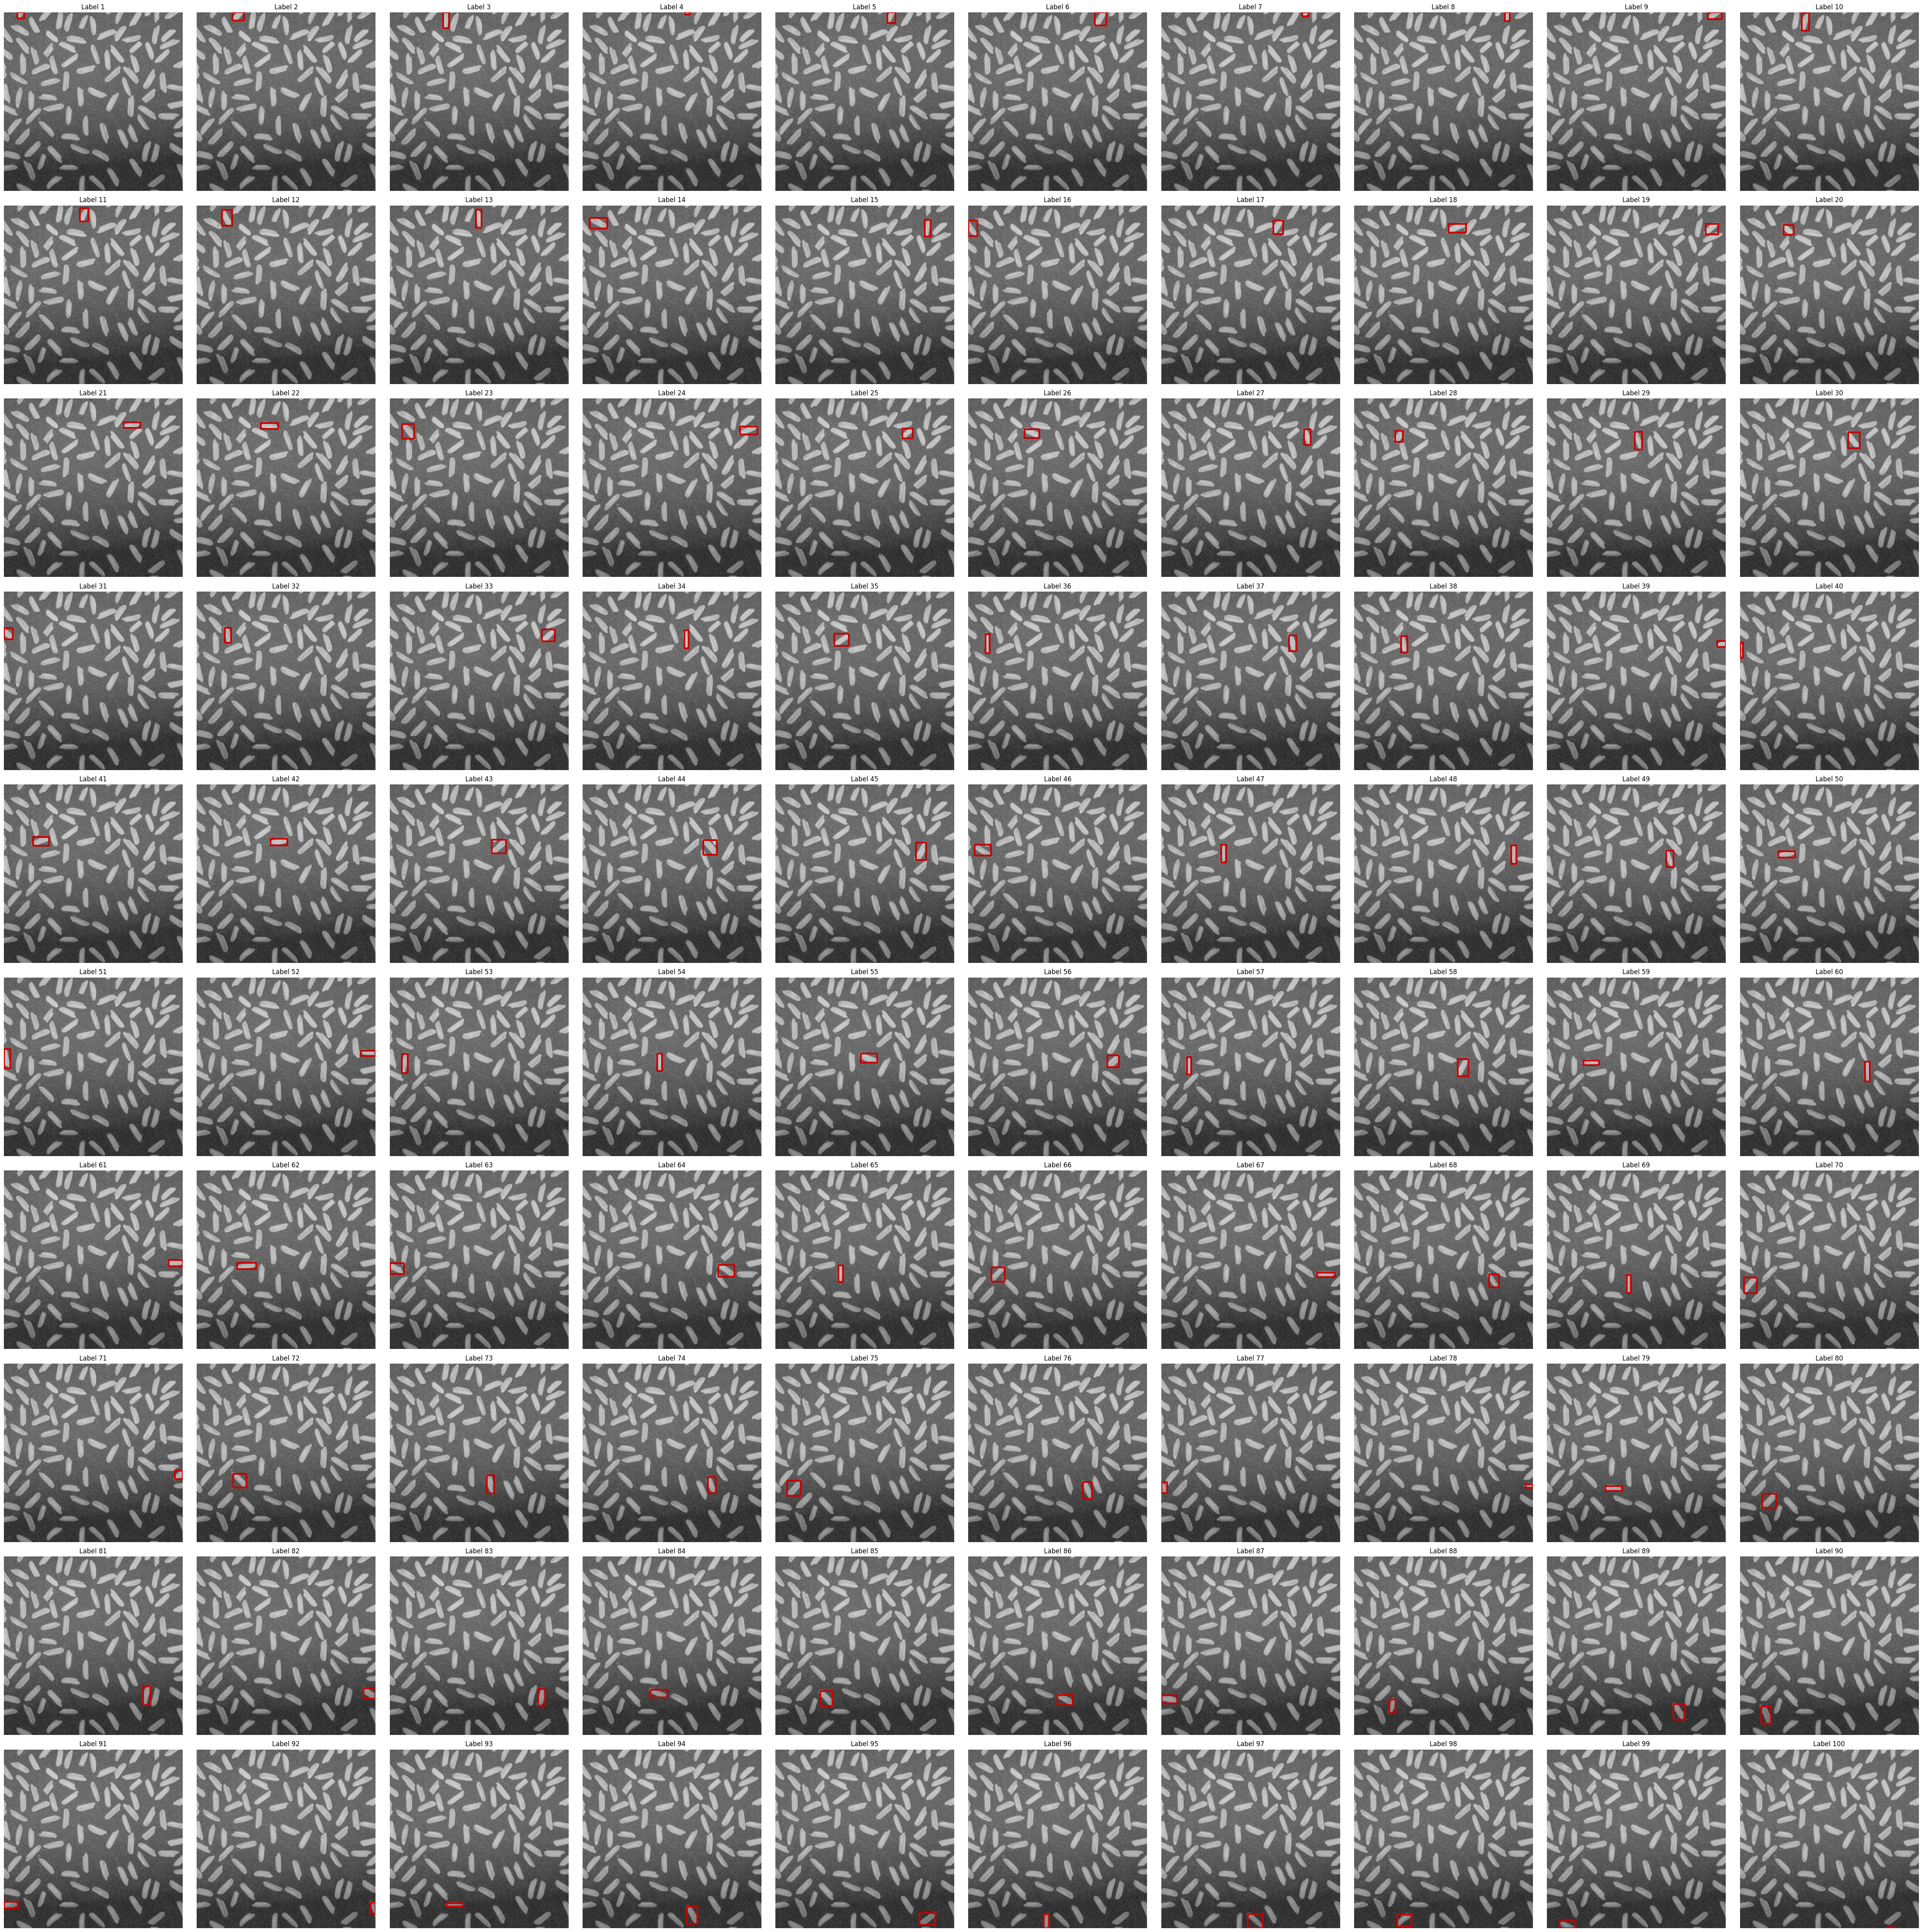

In [166]:
fig, axes = plt.subplots(10, 10, figsize=(50, 50))
num_labels = stats_filtered.shape[0]

for i, ax in zip(range(num_labels), axes.flatten()):
    x = stats_filtered[i, cv2.CC_STAT_LEFT]
    y = stats_filtered[i, cv2.CC_STAT_TOP]
    w = stats_filtered[i, cv2.CC_STAT_WIDTH]
    h = stats_filtered[i, cv2.CC_STAT_HEIGHT]
    area = stats_filtered[i, cv2.CC_STAT_AREA]
    output = rice.copy()
    cv2.rectangle(output, (x, y), (x + w, y + h), 200, 3)
    plot_grayscale(output, ax, True, title=f"Label {i+1}")

fig.tight_layout()
plt.show()

## Exercise 2 (filters with Fourier Transform)

(480, 640)


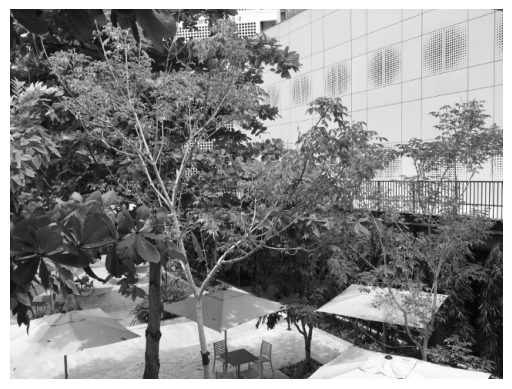

In [172]:
IMAGE_URL = 'https://github.com/agmarrugo/computer-vision-utb/raw/main/data/utb-alcatraz.jpg'

urllib.request.urlretrieve(IMAGE_URL, 'images/utb.png')

utb = cv2.imread('images/utb.png')

img_utb = cv2.cvtColor(utb, cv2.COLOR_BGR2GRAY)
print(img_utb.shape)

plt.imshow(img_utb, cmap='gray')
plt.axis('off')
plt.show()

**TODO: Compute the Fourier spectrum of the previously loaded image. (hint: use the functions `np.fft.fft2` and `np.fft.fftshift`)**

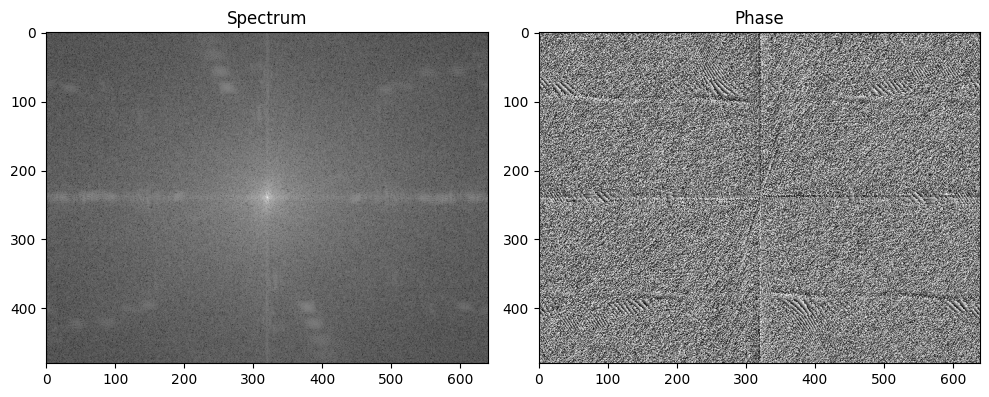

In [173]:
spectrum = np.fft.fft2(img_utb)
spectrum_shifted = np.fft.fftshift(spectrum)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_grayscale(np.log(np.abs(spectrum_shifted)), axes[0], False, title='Spectrum')
plot_grayscale(np.angle(spectrum_shifted), axes[1], False, title='Phase')
fig.tight_layout()
plt.show()

In [174]:
def distance(point1,point2):
    return np.sqrt((point1[0]-point2[0])**2 + (point1[1]-point2[1])**2)

def gaussianLP(D0,imgShape):
    base = np.zeros(imgShape[:2])
    rows, cols = imgShape[:2]
    center = (rows/2,cols/2)
    for x in range(cols):
        for y in range(rows):
            base[y,x] = np.exp(((-distance((y,x),center)**2)/(2*(D0**2))))
    return base

def gaussianHP(D0,imgShape):
    base = np.zeros(imgShape[:2])
    rows, cols = imgShape[:2]
    center = (rows/2,cols/2)
    for x in range(cols):
        for y in range(rows):
            base[y,x] = 1 - np.exp(((-distance((y,x),center)**2)/(2*(D0**2))))
    return base

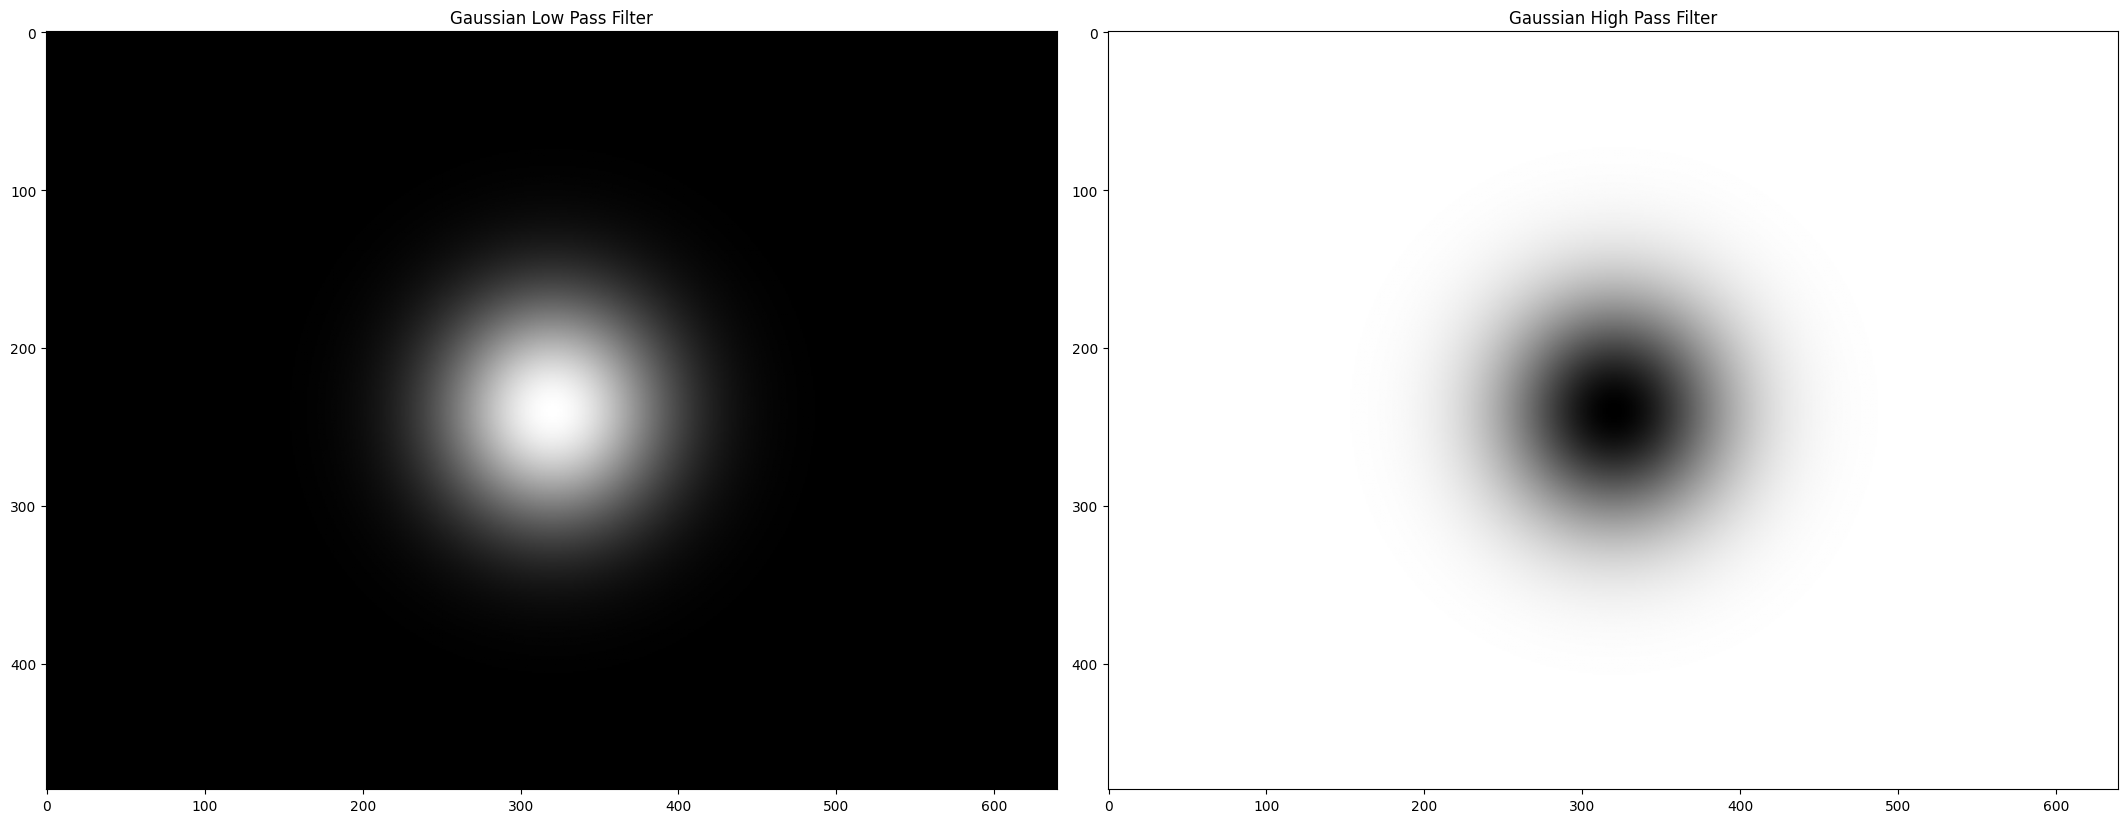

In [175]:
plt.figure(figsize=(6.4*5, 4.8*5), constrained_layout=False)

LowPass = gaussianLP(50,img_utb.shape)
plt.subplot(131), plt.imshow(LowPass, "gray"), plt.title("Gaussian Low Pass Filter")

HighPass = gaussianHP(50,img_utb.shape)
plt.subplot(132), plt.imshow(HighPass, "gray"), plt.title("Gaussian High Pass Filter")

plt.tight_layout()
plt.show()

**TODO: Filter the image with the above filters. Remember that filtering in the FFT domain is simple multiplication. # Tip: to get a meaningful image, you have to use `np.fft.ifftshift` after the spectra multiplication.**

**You should already have the FFT of the UTB image from previous TODO**

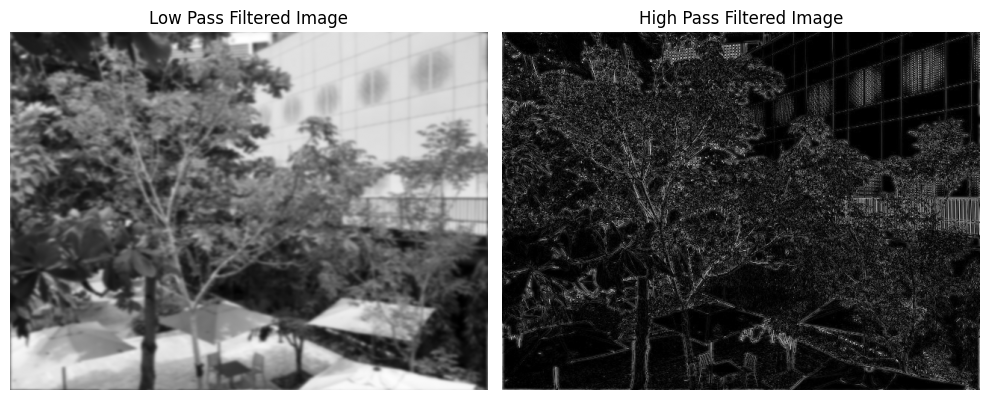

In [176]:
result1 = spectrum_shifted * LowPass
result1 = np.fft.ifftshift(result1)
result1 = np.fft.ifft2(result1)
result1 = np.abs(result1)

result2 = spectrum_shifted * HighPass
result2 = np.fft.ifftshift(result2)
result2 = np.fft.ifft2(result2)
result2 = np.abs(result2)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plot_grayscale(result1, axes[0], title='Low Pass Filtered Image')
plot_grayscale(result2, axes[1], title='High Pass Filtered Image')
fig.tight_layout()
plt.show()

In [159]:
# Buenísimo. Nunca me deja de sorprender lo que se puede hacer con la FFT.